# toy1 — Pearson correlations under 4 filter modes

For each metric vs accuracy, plot and compute Pearson *r* in four modes side by side:

1. **as-is** — all items
2. **no denied** — drop items where `satisfaction_level == Denied`
3. **drop denied with no code** — drop items that are denied *and* have empty `code_location` (keep denied items that have code)
4. **has code** — drop items with empty `code_location`

Includes original metrics from `toy.ipynb` plus metrics from `10.complexity2/data_metrics.json`.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# accuracy

In [2]:
with open('../8.Accuracy/data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

accuracy_data = {}
satisfaction_data = {}
has_code_location = {}
for nfr in data:
    nfr_id = nfr['id']
    llm_response = nfr['llm_response']
    gt_label = nfr['satisfaction_level'].lower()
    if gt_label == 'satisfied':
        gt = 4
    elif gt_label == 'weakly satisfied':
        gt = 3
    elif gt_label == 'weakly denied':
        gt = 2
    elif gt_label == 'denied':
        gt = 1
    else:
        raise Exception(nfr_id)
    accuracy_data[nfr_id] = 1 - abs(gt - llm_response) / 3
    satisfaction_data[nfr_id] = nfr['satisfaction_level']
    locs = nfr.get('code_location') or []
    has_code_location[nfr_id] = len(locs) > 0

# complexity

In [3]:
with open('../4.NFRComplexity/data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

complexity_data = {}
for nfr in data:
    complexity_data[nfr['id']] = nfr['complexity']

# tracability

In [4]:
with open('../6.NFRTracability/data-tracability.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

locc_data = {}
cdc_data = {}
cdo_data = {}
docs_data = {}
docm_data = {}
for nfr in data:
    nfr_id = nfr['id']
    locc_data[nfr_id] = nfr['locc']
    cdc_data[nfr_id] = nfr['cdc']
    cdo_data[nfr_id] = nfr['cdo']
    docs_data[nfr_id] = nfr['docs']
    docm_data[nfr_id] = nfr['docm']

# ambiguity

In [5]:
with open('../3.NFRAmbiguity/data_annotated.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

lexical_data = {}
syntactic_data = {}
semantic_data = {}
vagueness_data = {}
incompleteness_data = {}
referential_data = {}
ambiguity_exists_data = {}
sum_ambiguity_data = {}
for nfr in data:
    nfr_id = nfr['id']
    lexical_data[nfr_id] = nfr['Lexical']
    syntactic_data[nfr_id] = nfr['Syntactic']
    semantic_data[nfr_id] = nfr['Semantic']
    vagueness_data[nfr_id] = nfr['Vagueness']
    incompleteness_data[nfr_id] = nfr['Incompleteness']
    referential_data[nfr_id] = nfr['Referential']
    ambiguity_flags = [
        nfr['Lexical'], nfr['Syntactic'], nfr['Semantic'],
        nfr['Vagueness'], nfr['Incompleteness'], nfr['Referential'],
    ]
    ambiguity_exists_data[nfr_id] = any(ambiguity_flags)
    sum_ambiguity_data[nfr_id] = sum(ambiguity_flags)

# complexity2 metrics (`data_metrics.json`)

In [6]:
with open('../10.complexity2/data_metrics.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# Collect all metric names; skip Entity Coherence (all null in this dataset)
complexity2_metric_names = list(data[0]['metrics'].keys())
complexity2_metric_names = [
    m for m in complexity2_metric_names
    if any(nfr['metrics'].get(m) is not None for nfr in data)
]

complexity2_data = {m: {} for m in complexity2_metric_names}
for nfr in data:
    nfr_id = nfr['id']
    for m in complexity2_metric_names:
        complexity2_data[m][nfr_id] = nfr['metrics'].get(m)

print(f'Loaded {len(complexity2_metric_names)} complexity2 metrics:')
for m in complexity2_metric_names:
    print(' -', m)

Loaded 11 complexity2 metrics:
 - Consensus grade level (Readability)
 - Headings count (Structure)
 - Headings per sentence (Structure)
 - List items count (Structure)
 - Lists per sentence (Structure)
 - SMAO sentences count (Requirements)
 - SMAO sentences % (Requirements)
 - Vague words per sentence (Requirements)
 - Anaphora per sentence (Requirements)
 - Sentence CV (Requirements)
 - CPRE terms per sentence (CPRE)


# combine all

In [7]:
df = pd.DataFrame({
    'accuracy': accuracy_data,
    'satisfaction': satisfaction_data,
    'has_code_location': has_code_location,
    'complexity': complexity_data,
    'locc': locc_data,
    'cdc': cdc_data,
    'cdo': cdo_data,
    'docs': docs_data,
    'docm': docm_data,
    'lexical': lexical_data,
    'syntactic': syntactic_data,
    'semantic': semantic_data,
    'vagueness': vagueness_data,
    'incompleteness': incompleteness_data,
    'referential': referential_data,
    'ambiguity_exists': ambiguity_exists_data,
    'sum_ambiguity': sum_ambiguity_data,
})
for m in complexity2_metric_names:
    df[m] = pd.Series(complexity2_data[m])

df.index.name = 'id'
df = df.reset_index()
df['is_denied'] = df['satisfaction'].str.lower() == 'denied'
df.head()

,id,accuracy,satisfaction,has_code_location,complexity,locc,cdc,cdo,docs,docm,...,Headings per sentence (Structure),List items count (Structure),Lists per sentence (Structure),SMAO sentences count (Requirements),SMAO sentences % (Requirements),Vague words per sentence (Requirements),Anaphora per sentence (Requirements),Sentence CV (Requirements),CPRE terms per sentence (CPRE),is_denied
0,1,1.000000,Satisfied,True,1,63,3,4,0.688587,0.627125,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
1,2,1.000000,Satisfied,True,0,23,5,5,0.879017,0.898760,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
2,3,1.000000,Satisfied,True,0,73,2,2,0.968287,0.962191,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
3,4,0.666667,Satisfied,True,0,15,1,2,0.000000,0.960000,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
4,5,0.666667,Weakly Denied,True,1,13,2,2,0.946746,0.946746,...,0.0,0,0.0,1,100.0,1.0,0.0,0.0,2.0,False


# plot: 4 modes side by side

Modes:
1. as-is
2. remove denied
3. remove items that are denied **and** have no code locations (keep denied that have code)
4. remove empty code locations

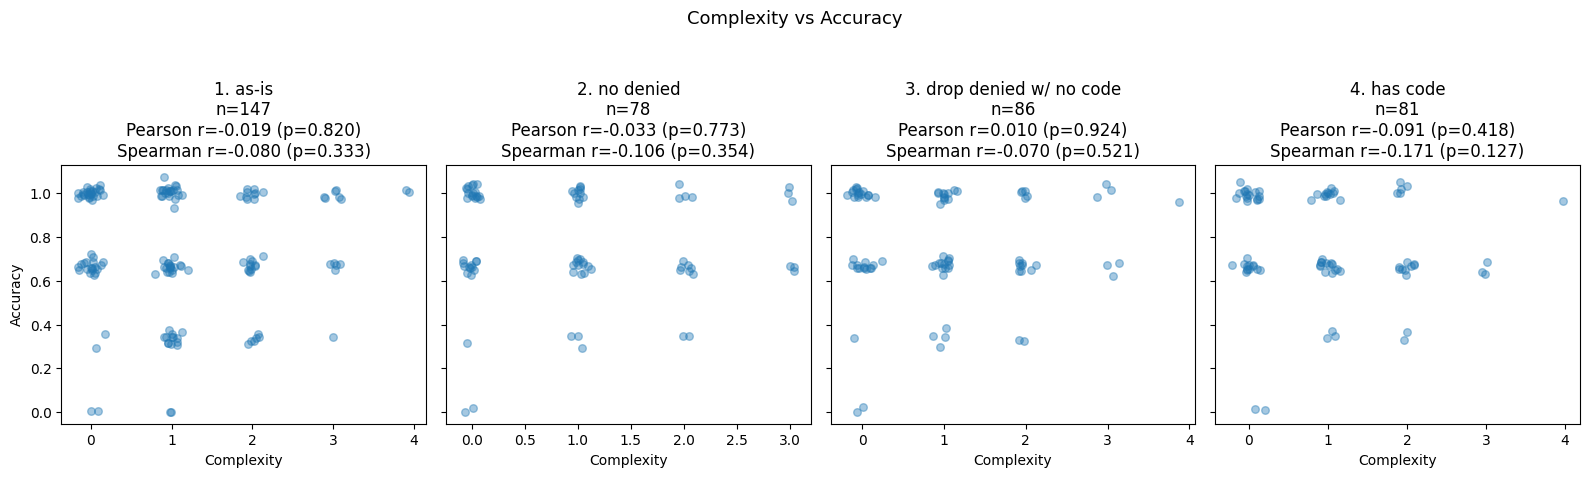

Complexity | 1. as-is: Pearson r=-0.019 (p=0.820), Spearman r=-0.080 (p=0.333), n=147
Complexity | 2. no denied: Pearson r=-0.033 (p=0.773), Spearman r=-0.106 (p=0.354), n=78
Complexity | 3. drop denied w/ no code: Pearson r=0.010 (p=0.924), Spearman r=-0.070 (p=0.521), n=86
Complexity | 4. has code: Pearson r=-0.091 (p=0.418), Spearman r=-0.171 (p=0.127), n=81



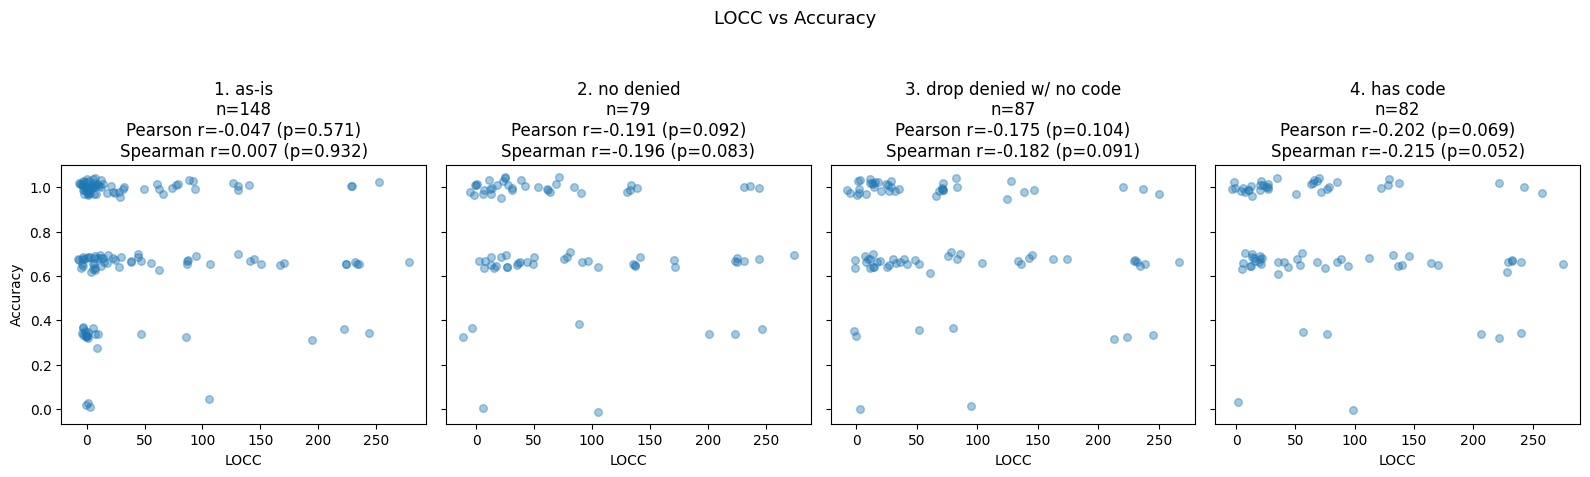

LOCC | 1. as-is: Pearson r=-0.047 (p=0.571), Spearman r=0.007 (p=0.932), n=148
LOCC | 2. no denied: Pearson r=-0.191 (p=0.092), Spearman r=-0.196 (p=0.083), n=79
LOCC | 3. drop denied w/ no code: Pearson r=-0.175 (p=0.104), Spearman r=-0.182 (p=0.091), n=87
LOCC | 4. has code: Pearson r=-0.202 (p=0.069), Spearman r=-0.215 (p=0.052), n=82



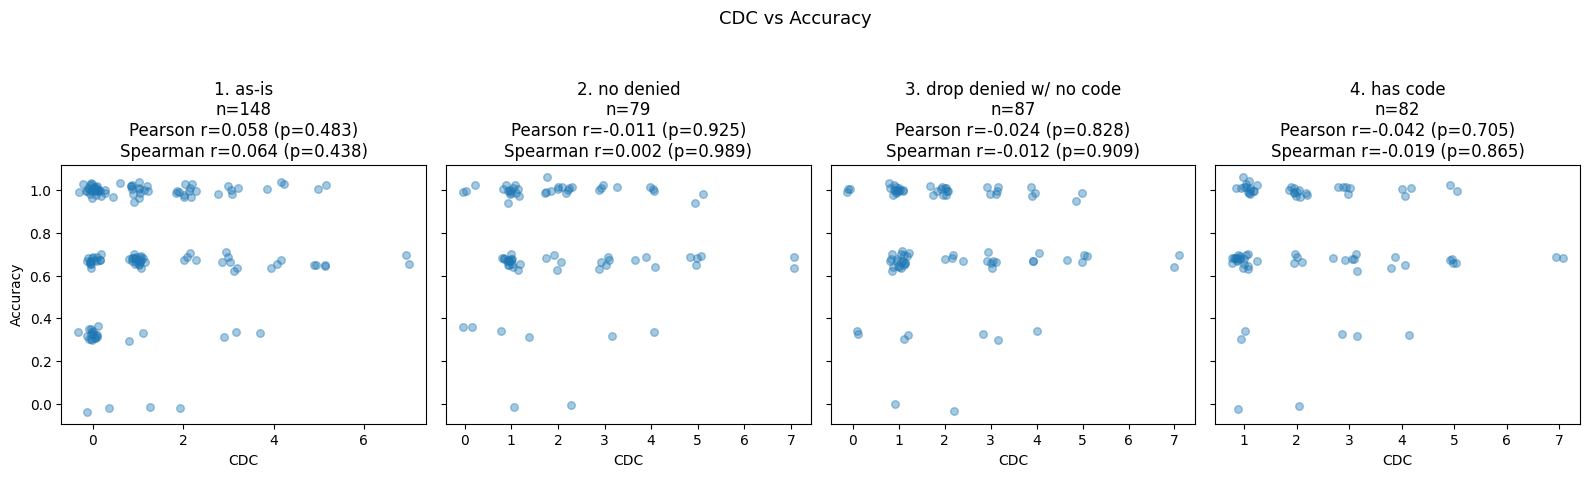

CDC | 1. as-is: Pearson r=0.058 (p=0.483), Spearman r=0.064 (p=0.438), n=148
CDC | 2. no denied: Pearson r=-0.011 (p=0.925), Spearman r=0.002 (p=0.989), n=79
CDC | 3. drop denied w/ no code: Pearson r=-0.024 (p=0.828), Spearman r=-0.012 (p=0.909), n=87
CDC | 4. has code: Pearson r=-0.042 (p=0.705), Spearman r=-0.019 (p=0.865), n=82



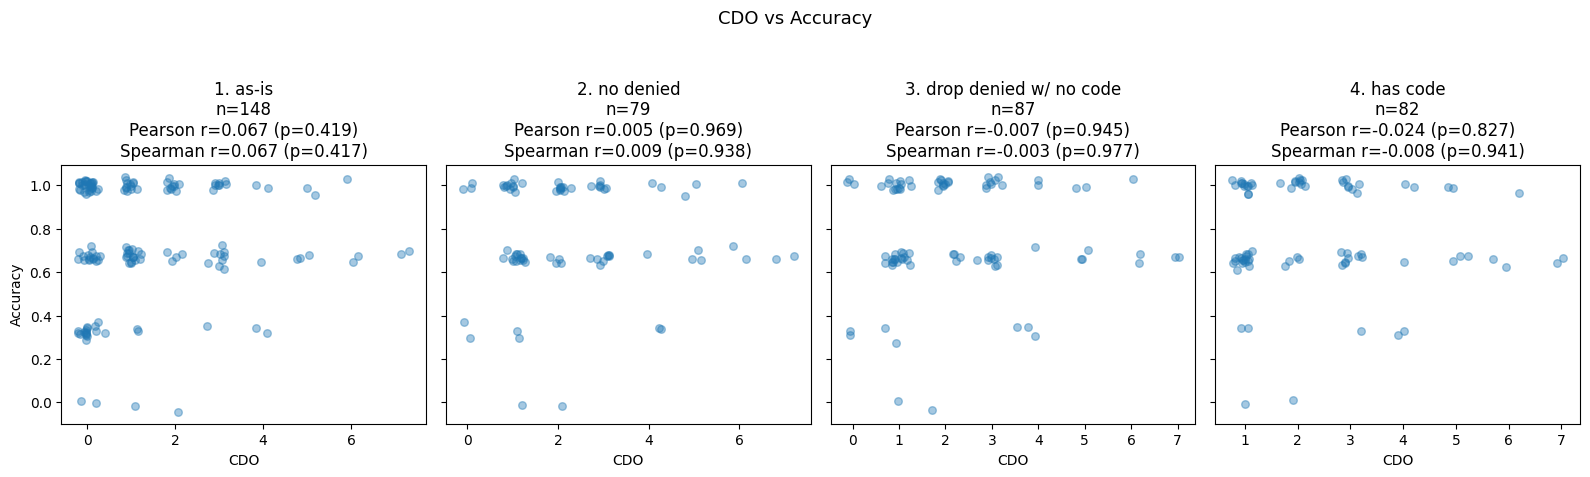

CDO | 1. as-is: Pearson r=0.067 (p=0.419), Spearman r=0.067 (p=0.417), n=148
CDO | 2. no denied: Pearson r=0.005 (p=0.969), Spearman r=0.009 (p=0.938), n=79
CDO | 3. drop denied w/ no code: Pearson r=-0.007 (p=0.945), Spearman r=-0.003 (p=0.977), n=87
CDO | 4. has code: Pearson r=-0.024 (p=0.827), Spearman r=-0.008 (p=0.941), n=82



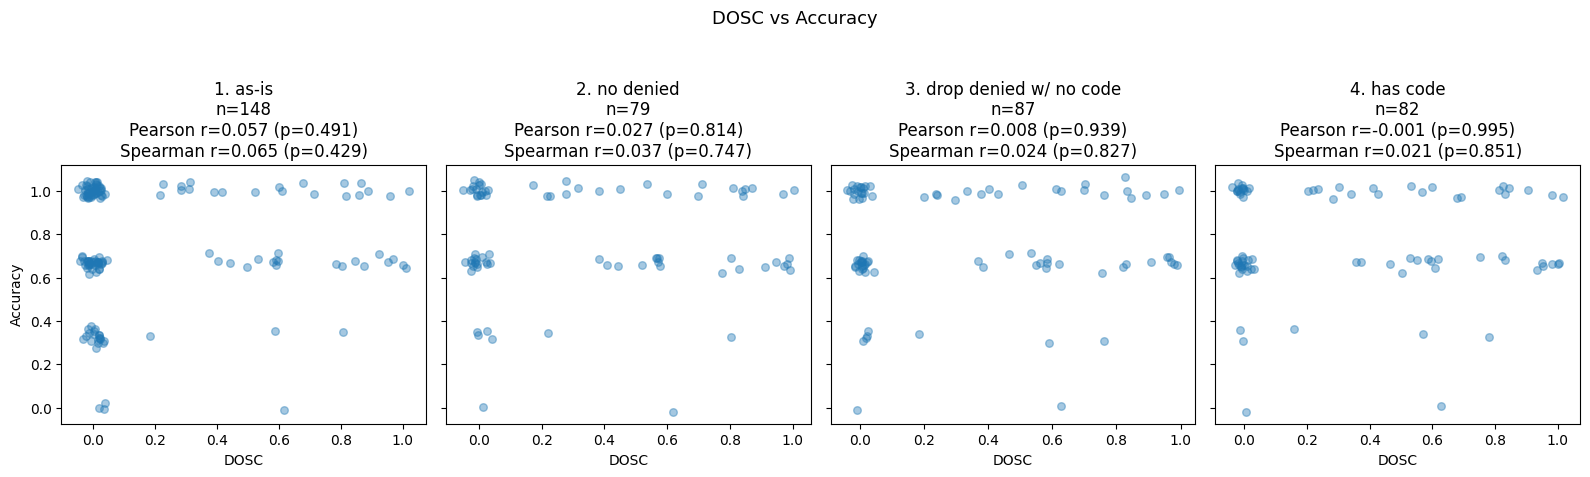

DOSC | 1. as-is: Pearson r=0.057 (p=0.491), Spearman r=0.065 (p=0.429), n=148
DOSC | 2. no denied: Pearson r=0.027 (p=0.814), Spearman r=0.037 (p=0.747), n=79
DOSC | 3. drop denied w/ no code: Pearson r=0.008 (p=0.939), Spearman r=0.024 (p=0.827), n=87
DOSC | 4. has code: Pearson r=-0.001 (p=0.995), Spearman r=0.021 (p=0.851), n=82



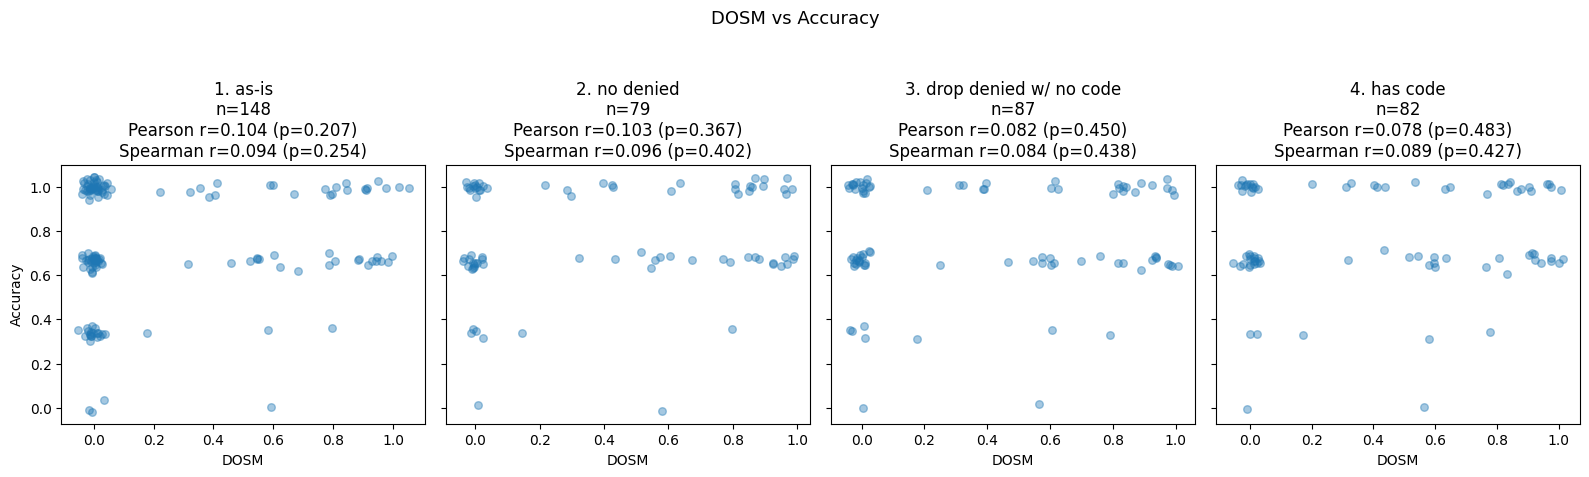

DOSM | 1. as-is: Pearson r=0.104 (p=0.207), Spearman r=0.094 (p=0.254), n=148
DOSM | 2. no denied: Pearson r=0.103 (p=0.367), Spearman r=0.096 (p=0.402), n=79
DOSM | 3. drop denied w/ no code: Pearson r=0.082 (p=0.450), Spearman r=0.084 (p=0.438), n=87
DOSM | 4. has code: Pearson r=0.078 (p=0.483), Spearman r=0.089 (p=0.427), n=82



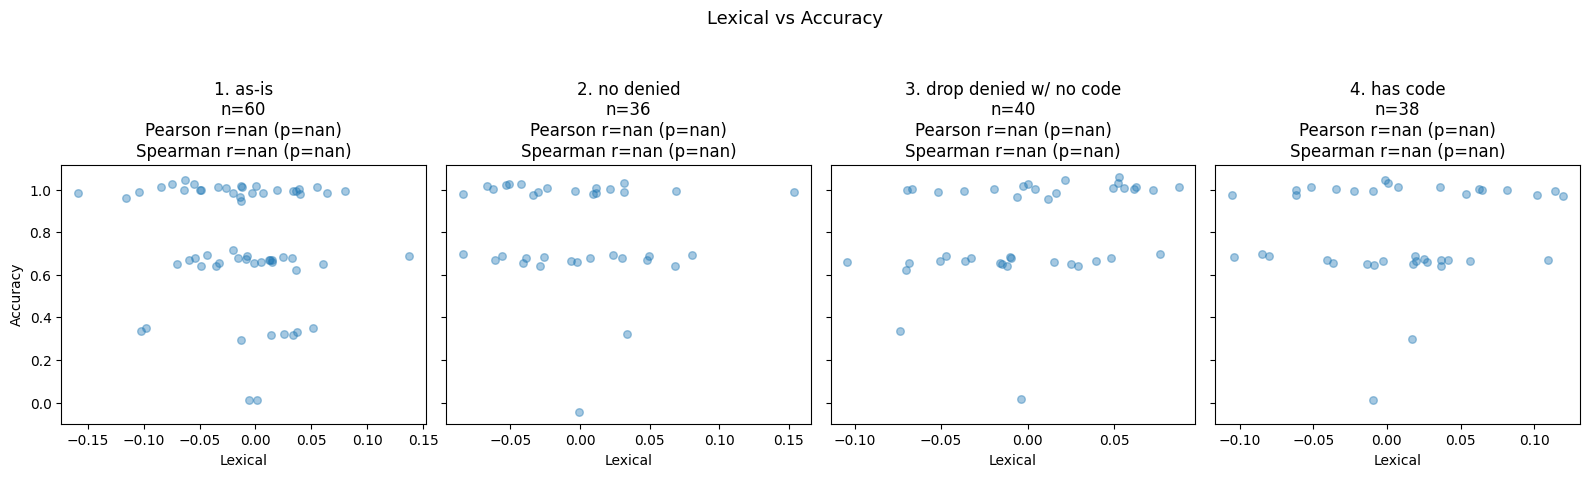

Lexical | 1. as-is: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=60
Lexical | 2. no denied: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=36
Lexical | 3. drop denied w/ no code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=40
Lexical | 4. has code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=38



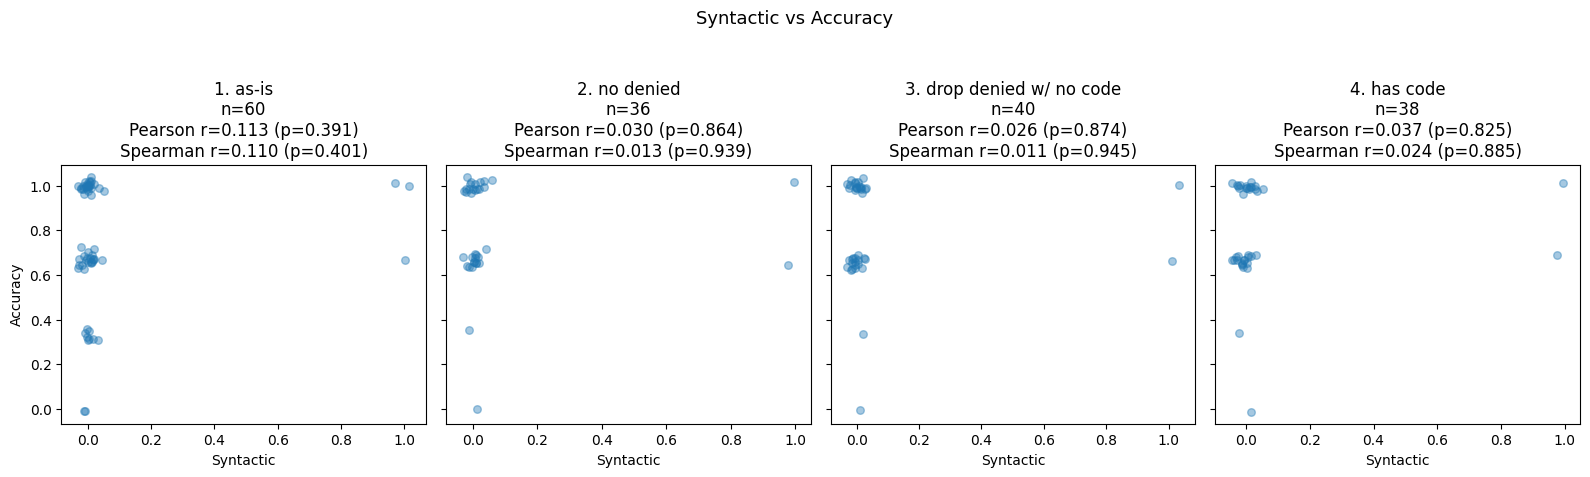

Syntactic | 1. as-is: Pearson r=0.113 (p=0.391), Spearman r=0.110 (p=0.401), n=60
Syntactic | 2. no denied: Pearson r=0.030 (p=0.864), Spearman r=0.013 (p=0.939), n=36
Syntactic | 3. drop denied w/ no code: Pearson r=0.026 (p=0.874), Spearman r=0.011 (p=0.945), n=40
Syntactic | 4. has code: Pearson r=0.037 (p=0.825), Spearman r=0.024 (p=0.885), n=38



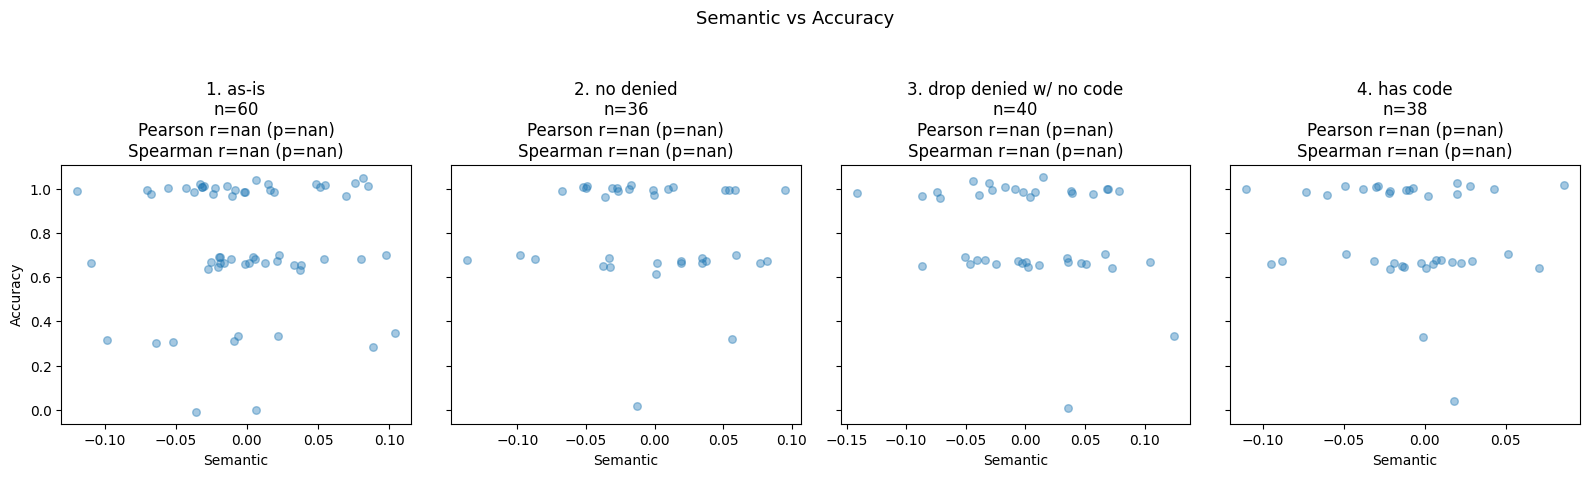

Semantic | 1. as-is: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=60
Semantic | 2. no denied: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=36
Semantic | 3. drop denied w/ no code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=40
Semantic | 4. has code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=38



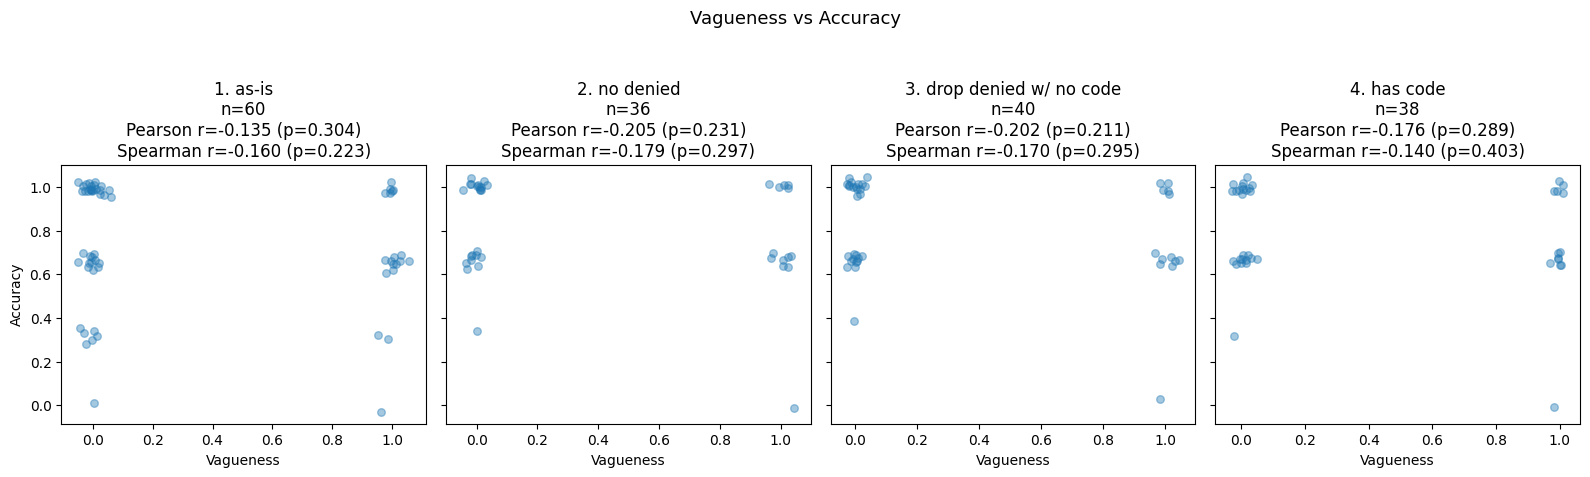

Vagueness | 1. as-is: Pearson r=-0.135 (p=0.304), Spearman r=-0.160 (p=0.223), n=60
Vagueness | 2. no denied: Pearson r=-0.205 (p=0.231), Spearman r=-0.179 (p=0.297), n=36
Vagueness | 3. drop denied w/ no code: Pearson r=-0.202 (p=0.211), Spearman r=-0.170 (p=0.295), n=40
Vagueness | 4. has code: Pearson r=-0.176 (p=0.289), Spearman r=-0.140 (p=0.403), n=38



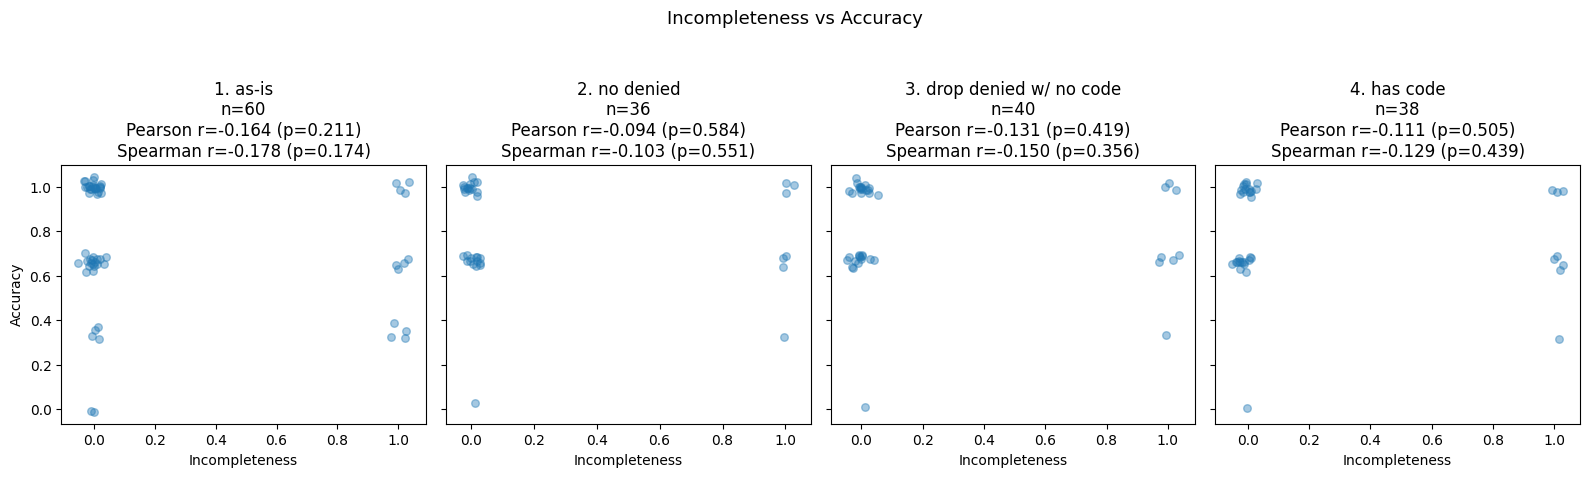

Incompleteness | 1. as-is: Pearson r=-0.164 (p=0.211), Spearman r=-0.178 (p=0.174), n=60
Incompleteness | 2. no denied: Pearson r=-0.094 (p=0.584), Spearman r=-0.103 (p=0.551), n=36
Incompleteness | 3. drop denied w/ no code: Pearson r=-0.131 (p=0.419), Spearman r=-0.150 (p=0.356), n=40
Incompleteness | 4. has code: Pearson r=-0.111 (p=0.505), Spearman r=-0.129 (p=0.439), n=38



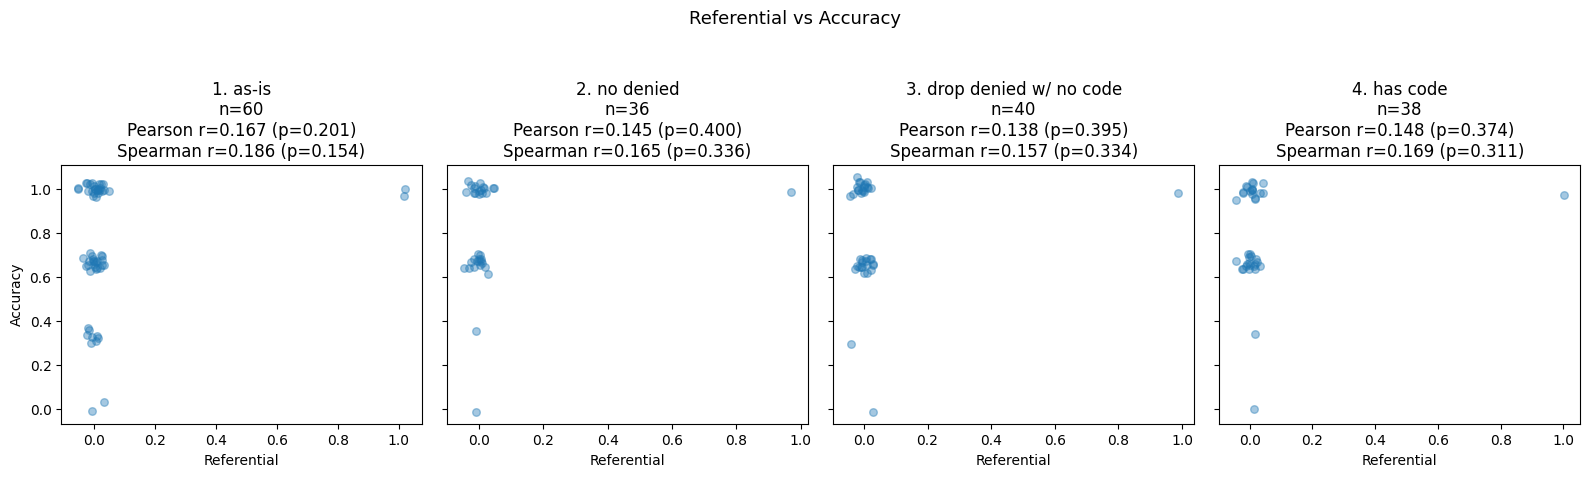

Referential | 1. as-is: Pearson r=0.167 (p=0.201), Spearman r=0.186 (p=0.154), n=60
Referential | 2. no denied: Pearson r=0.145 (p=0.400), Spearman r=0.165 (p=0.336), n=36
Referential | 3. drop denied w/ no code: Pearson r=0.138 (p=0.395), Spearman r=0.157 (p=0.334), n=40
Referential | 4. has code: Pearson r=0.148 (p=0.374), Spearman r=0.169 (p=0.311), n=38



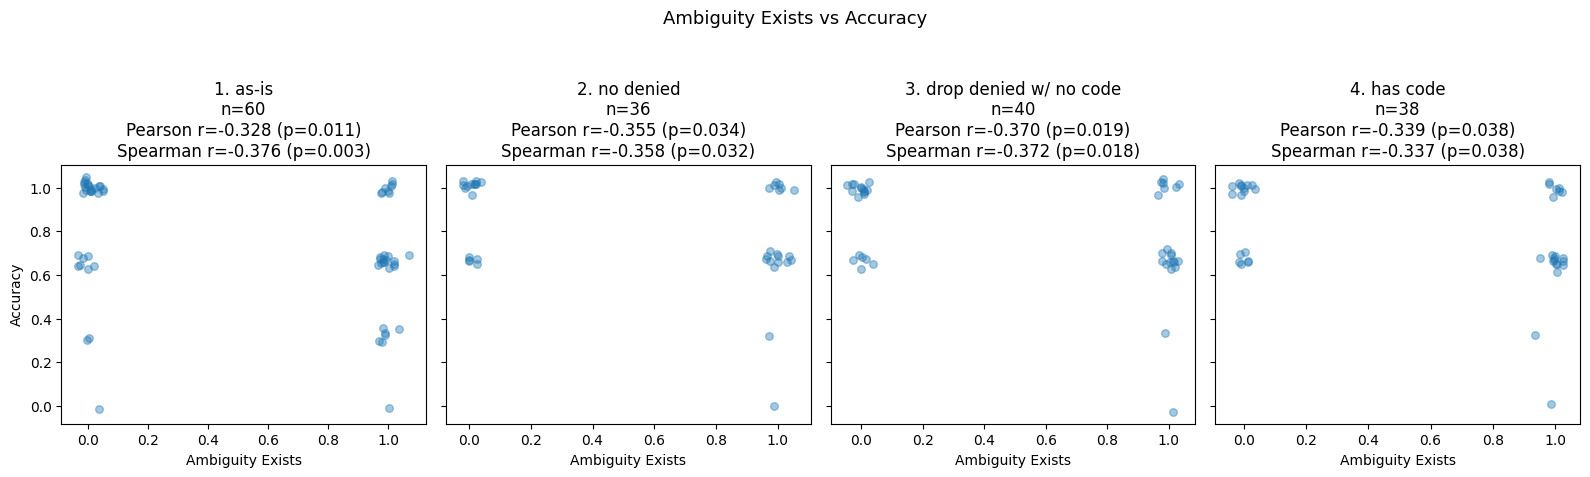

Ambiguity Exists | 1. as-is: Pearson r=-0.328 (p=0.011), Spearman r=-0.376 (p=0.003), n=60
Ambiguity Exists | 2. no denied: Pearson r=-0.355 (p=0.034), Spearman r=-0.358 (p=0.032), n=36
Ambiguity Exists | 3. drop denied w/ no code: Pearson r=-0.370 (p=0.019), Spearman r=-0.372 (p=0.018), n=40
Ambiguity Exists | 4. has code: Pearson r=-0.339 (p=0.038), Spearman r=-0.337 (p=0.038), n=38



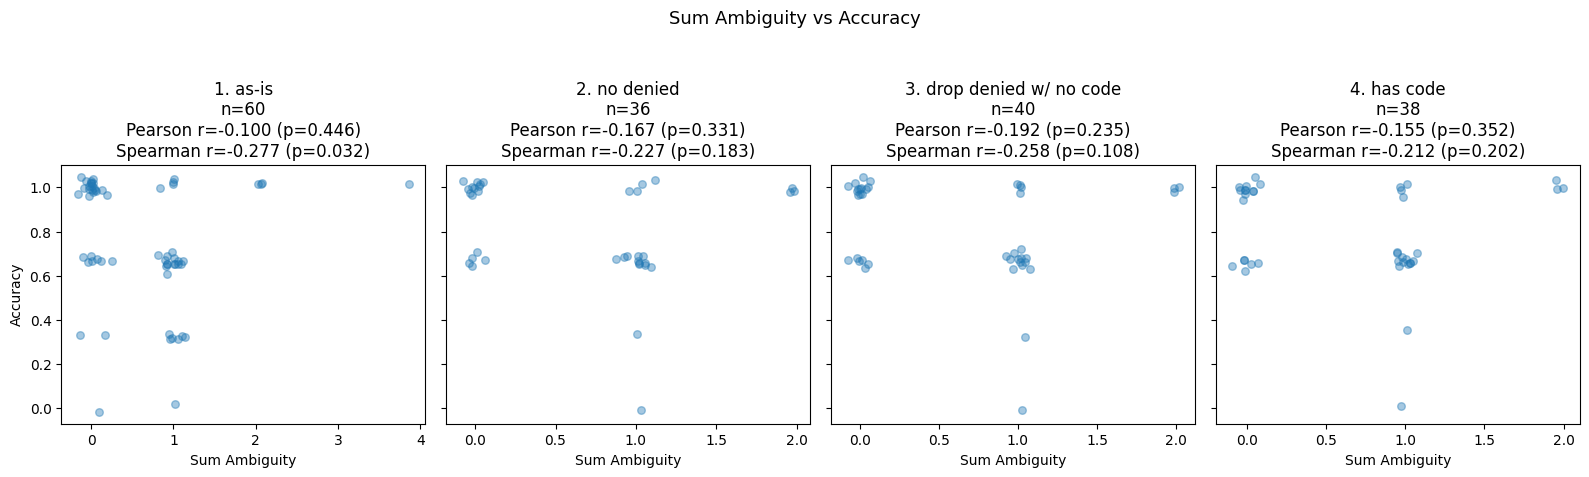

Sum Ambiguity | 1. as-is: Pearson r=-0.100 (p=0.446), Spearman r=-0.277 (p=0.032), n=60
Sum Ambiguity | 2. no denied: Pearson r=-0.167 (p=0.331), Spearman r=-0.227 (p=0.183), n=36
Sum Ambiguity | 3. drop denied w/ no code: Pearson r=-0.192 (p=0.235), Spearman r=-0.258 (p=0.108), n=40
Sum Ambiguity | 4. has code: Pearson r=-0.155 (p=0.352), Spearman r=-0.212 (p=0.202), n=38



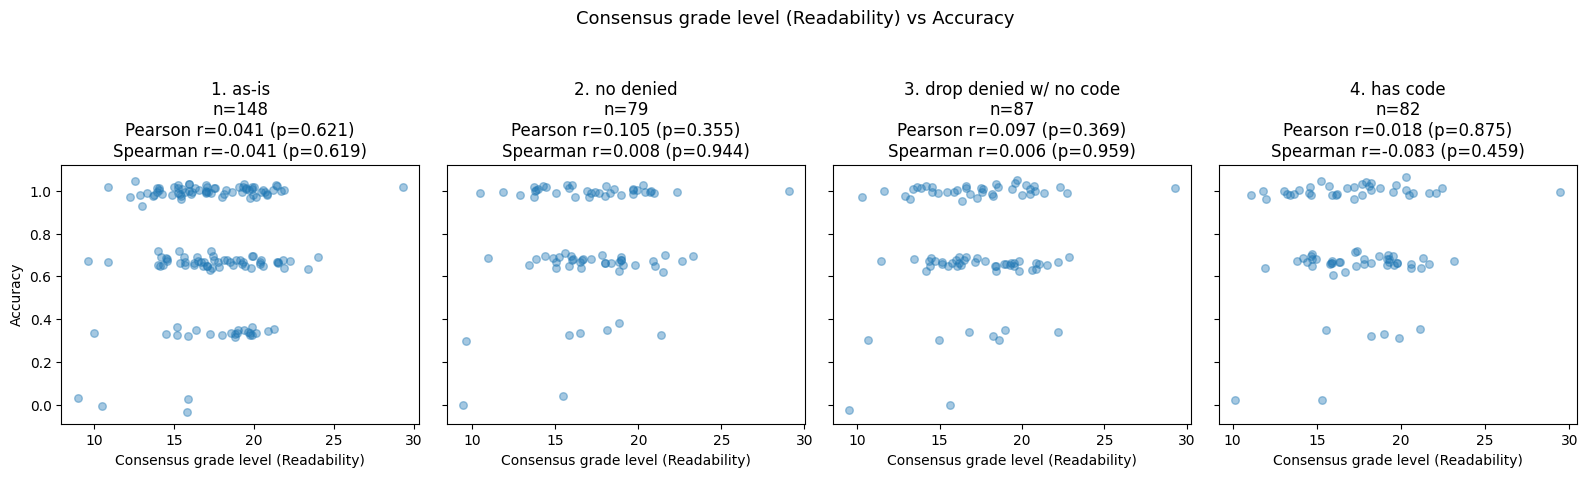

Consensus grade level (Readability) | 1. as-is: Pearson r=0.041 (p=0.621), Spearman r=-0.041 (p=0.619), n=148
Consensus grade level (Readability) | 2. no denied: Pearson r=0.105 (p=0.355), Spearman r=0.008 (p=0.944), n=79
Consensus grade level (Readability) | 3. drop denied w/ no code: Pearson r=0.097 (p=0.369), Spearman r=0.006 (p=0.959), n=87
Consensus grade level (Readability) | 4. has code: Pearson r=0.018 (p=0.875), Spearman r=-0.083 (p=0.459), n=82



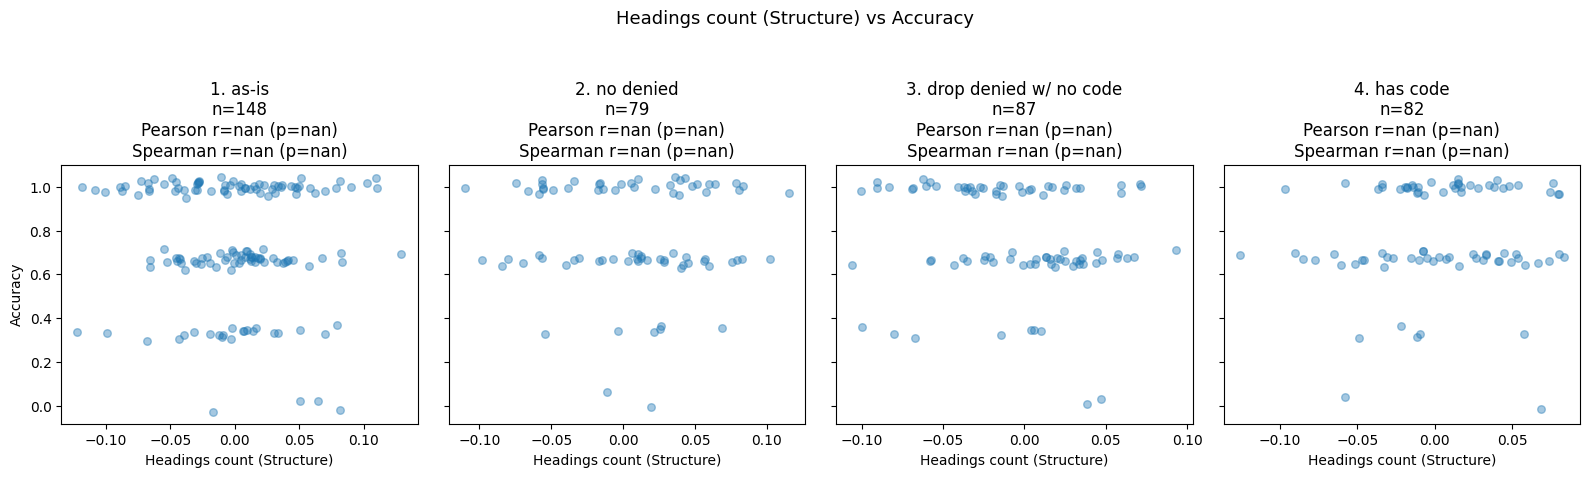

Headings count (Structure) | 1. as-is: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=148
Headings count (Structure) | 2. no denied: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=79
Headings count (Structure) | 3. drop denied w/ no code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=87
Headings count (Structure) | 4. has code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=82



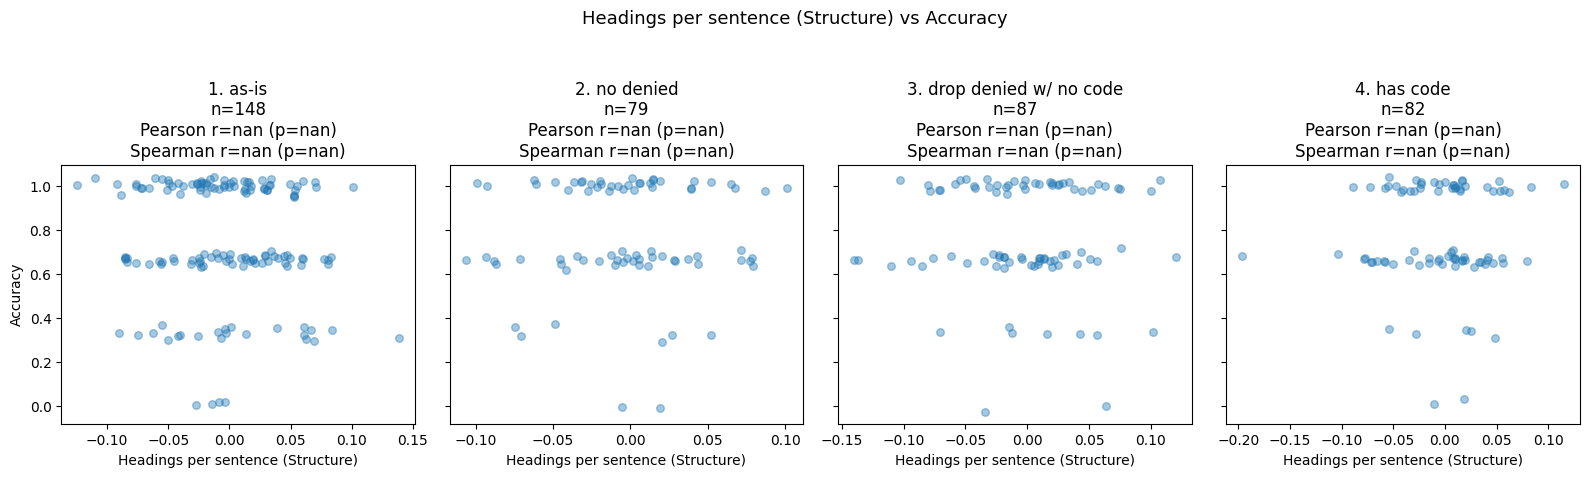

Headings per sentence (Structure) | 1. as-is: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=148
Headings per sentence (Structure) | 2. no denied: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=79
Headings per sentence (Structure) | 3. drop denied w/ no code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=87
Headings per sentence (Structure) | 4. has code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=82



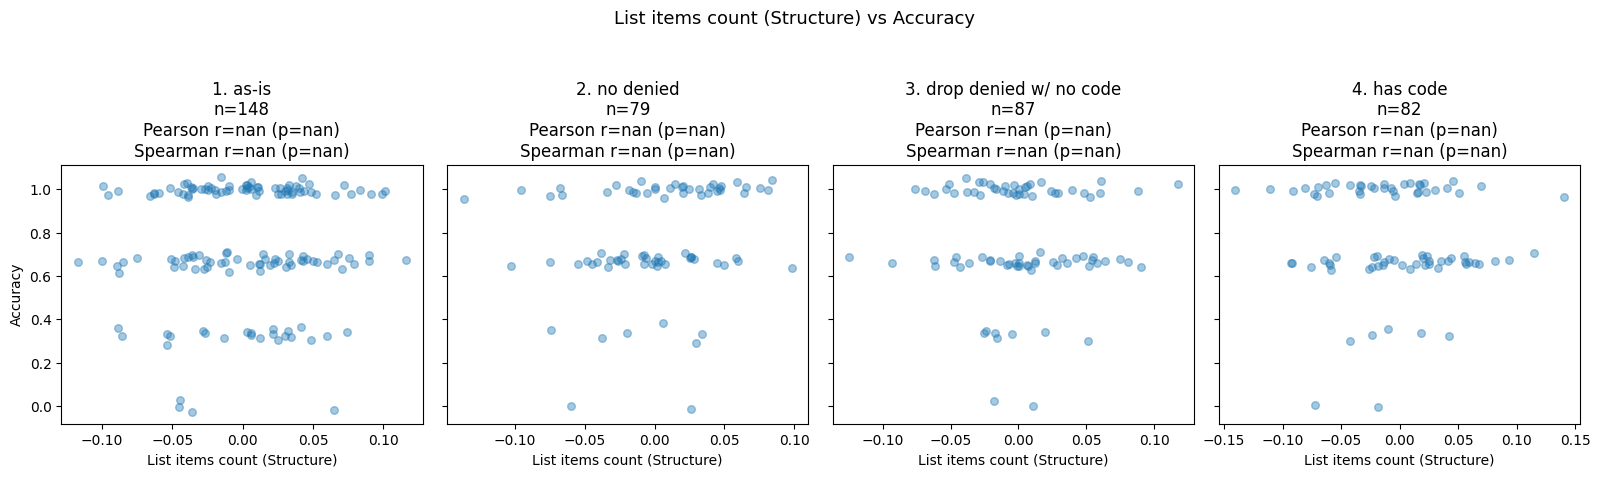

List items count (Structure) | 1. as-is: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=148
List items count (Structure) | 2. no denied: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=79
List items count (Structure) | 3. drop denied w/ no code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=87
List items count (Structure) | 4. has code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=82



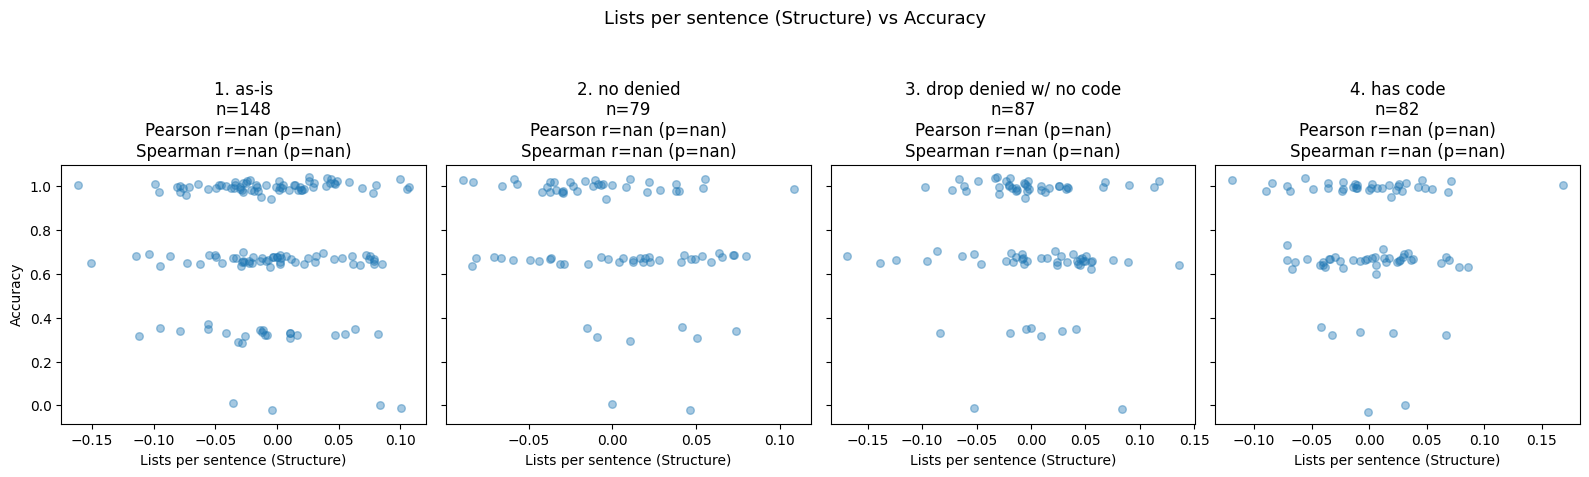

Lists per sentence (Structure) | 1. as-is: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=148
Lists per sentence (Structure) | 2. no denied: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=79
Lists per sentence (Structure) | 3. drop denied w/ no code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=87
Lists per sentence (Structure) | 4. has code: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=82



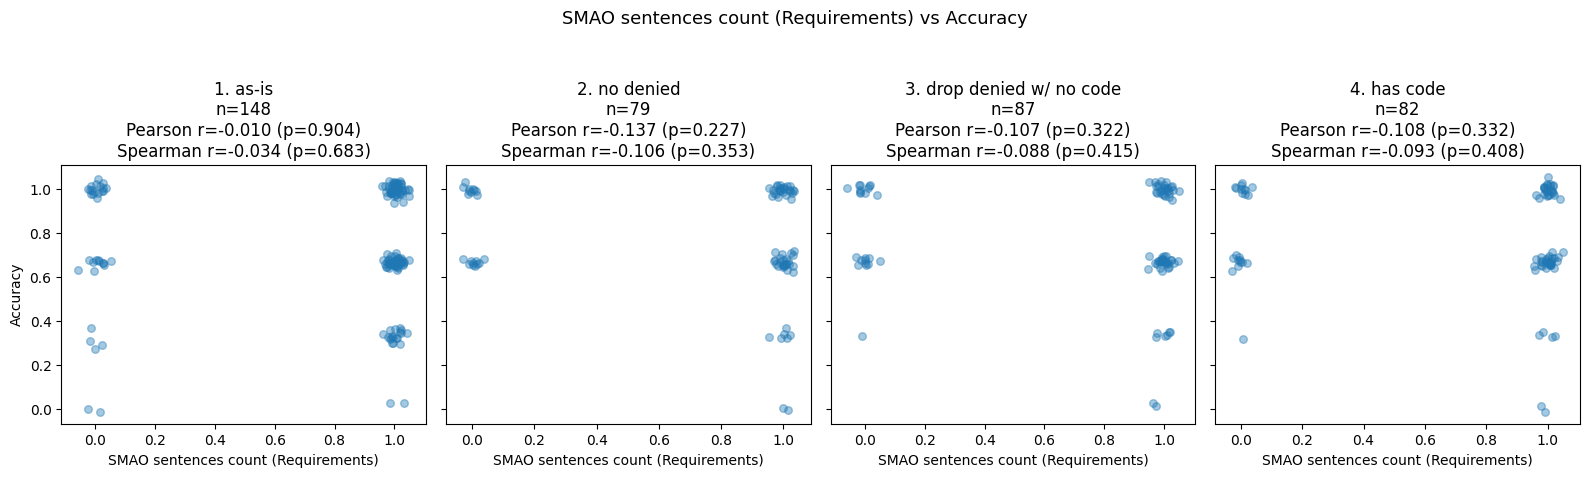

SMAO sentences count (Requirements) | 1. as-is: Pearson r=-0.010 (p=0.904), Spearman r=-0.034 (p=0.683), n=148
SMAO sentences count (Requirements) | 2. no denied: Pearson r=-0.137 (p=0.227), Spearman r=-0.106 (p=0.353), n=79
SMAO sentences count (Requirements) | 3. drop denied w/ no code: Pearson r=-0.107 (p=0.322), Spearman r=-0.088 (p=0.415), n=87
SMAO sentences count (Requirements) | 4. has code: Pearson r=-0.108 (p=0.332), Spearman r=-0.093 (p=0.408), n=82



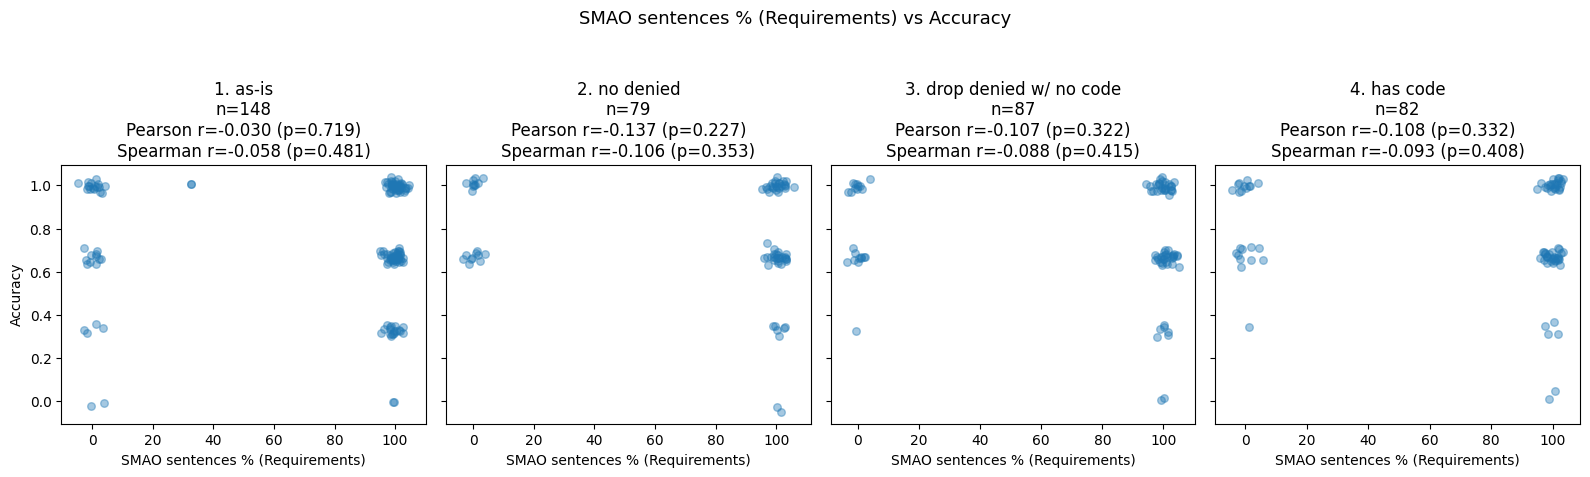

SMAO sentences % (Requirements) | 1. as-is: Pearson r=-0.030 (p=0.719), Spearman r=-0.058 (p=0.481), n=148
SMAO sentences % (Requirements) | 2. no denied: Pearson r=-0.137 (p=0.227), Spearman r=-0.106 (p=0.353), n=79
SMAO sentences % (Requirements) | 3. drop denied w/ no code: Pearson r=-0.107 (p=0.322), Spearman r=-0.088 (p=0.415), n=87
SMAO sentences % (Requirements) | 4. has code: Pearson r=-0.108 (p=0.332), Spearman r=-0.093 (p=0.408), n=82



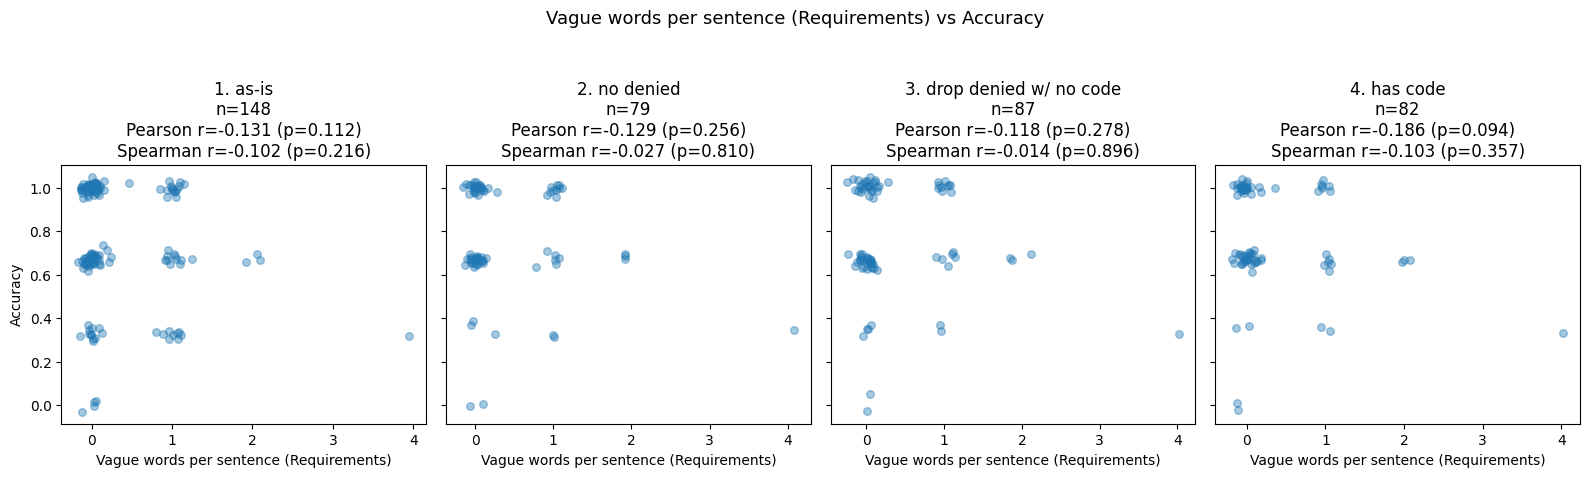

Vague words per sentence (Requirements) | 1. as-is: Pearson r=-0.131 (p=0.112), Spearman r=-0.102 (p=0.216), n=148
Vague words per sentence (Requirements) | 2. no denied: Pearson r=-0.129 (p=0.256), Spearman r=-0.027 (p=0.810), n=79
Vague words per sentence (Requirements) | 3. drop denied w/ no code: Pearson r=-0.118 (p=0.278), Spearman r=-0.014 (p=0.896), n=87
Vague words per sentence (Requirements) | 4. has code: Pearson r=-0.186 (p=0.094), Spearman r=-0.103 (p=0.357), n=82



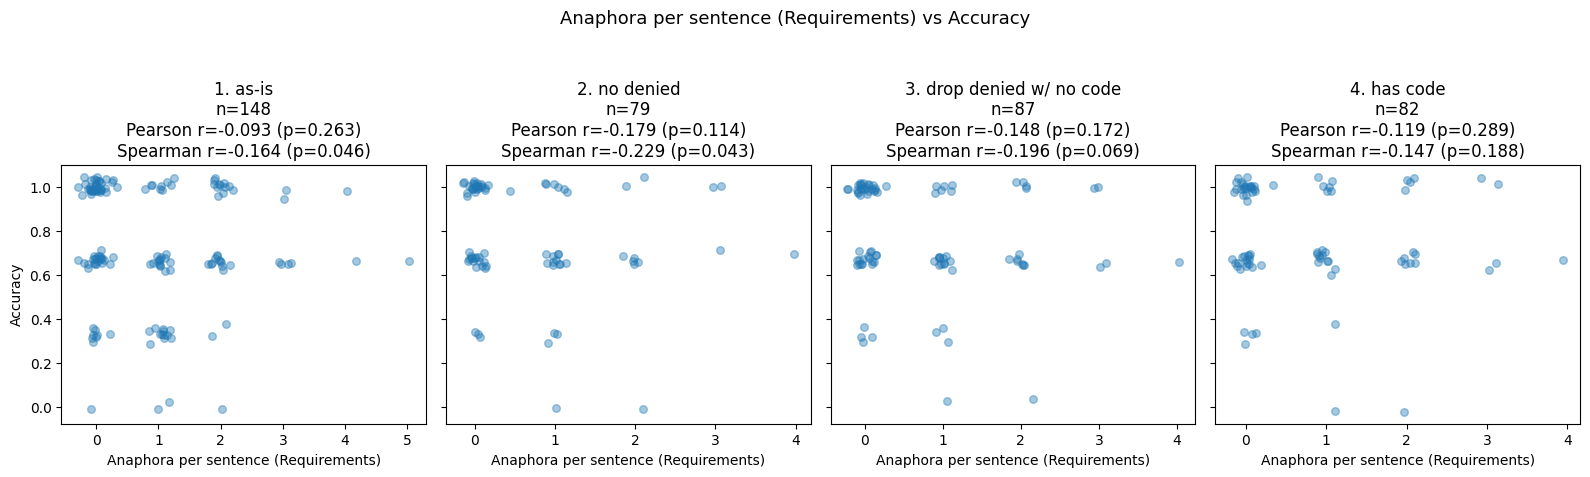

Anaphora per sentence (Requirements) | 1. as-is: Pearson r=-0.093 (p=0.263), Spearman r=-0.164 (p=0.046), n=148
Anaphora per sentence (Requirements) | 2. no denied: Pearson r=-0.179 (p=0.114), Spearman r=-0.229 (p=0.043), n=79
Anaphora per sentence (Requirements) | 3. drop denied w/ no code: Pearson r=-0.148 (p=0.172), Spearman r=-0.196 (p=0.069), n=87
Anaphora per sentence (Requirements) | 4. has code: Pearson r=-0.119 (p=0.289), Spearman r=-0.147 (p=0.188), n=82



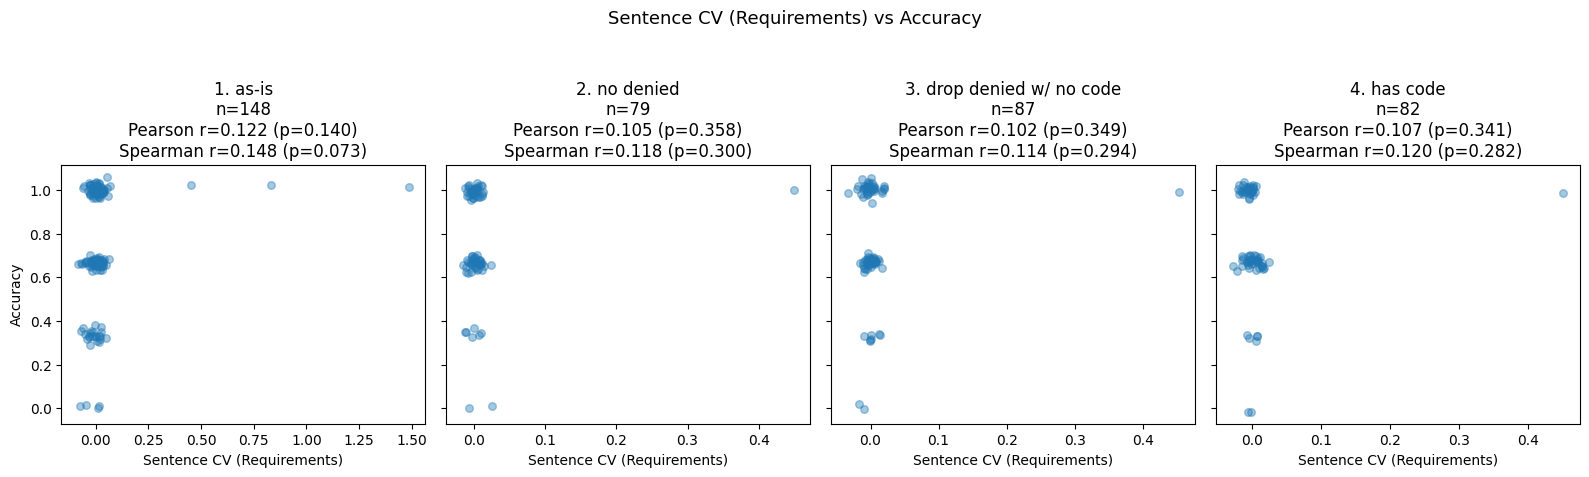

Sentence CV (Requirements) | 1. as-is: Pearson r=0.122 (p=0.140), Spearman r=0.148 (p=0.073), n=148
Sentence CV (Requirements) | 2. no denied: Pearson r=0.105 (p=0.358), Spearman r=0.118 (p=0.300), n=79
Sentence CV (Requirements) | 3. drop denied w/ no code: Pearson r=0.102 (p=0.349), Spearman r=0.114 (p=0.294), n=87
Sentence CV (Requirements) | 4. has code: Pearson r=0.107 (p=0.341), Spearman r=0.120 (p=0.282), n=82



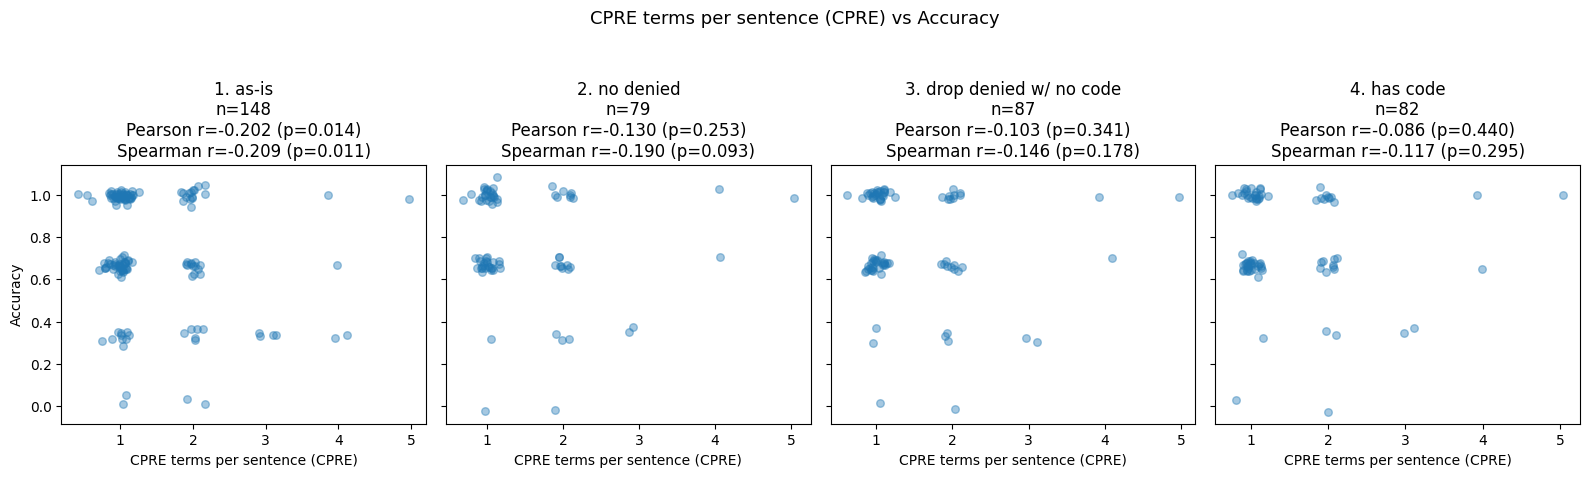

CPRE terms per sentence (CPRE) | 1. as-is: Pearson r=-0.202 (p=0.014), Spearman r=-0.209 (p=0.011), n=148
CPRE terms per sentence (CPRE) | 2. no denied: Pearson r=-0.130 (p=0.253), Spearman r=-0.190 (p=0.093), n=79
CPRE terms per sentence (CPRE) | 3. drop denied w/ no code: Pearson r=-0.103 (p=0.341), Spearman r=-0.146 (p=0.178), n=87
CPRE terms per sentence (CPRE) | 4. has code: Pearson r=-0.086 (p=0.440), Spearman r=-0.117 (p=0.295), n=82



,metric,mode,n,pearson_r,pearson_p,spearman_r,spearman_p
0,Complexity,1. as-is,147,-0.018929,0.819990,-0.080437,0.332801
1,Complexity,2. no denied,78,-0.033179,0.773058,-0.106388,0.353897
2,Complexity,3. drop denied w/ no code,86,0.010395,0.924323,-0.070163,0.520916
3,Complexity,4. has code,81,-0.091268,0.417746,-0.170836,0.127295
4,LOCC,1. as-is,148,-0.046917,0.571226,0.007125,0.931505
...,...,...,...,...,...,...,...
95,Sentence CV (Requirements),4. has code,82,0.106559,0.340675,0.120137,0.282337
96,CPRE terms per sentence (CPRE),1. as-is,148,-0.202440,0.013606,-0.208956,0.010812
97,CPRE terms per sentence (CPRE),2. no denied,79,-0.130258,0.252546,-0.190433,0.092754
98,CPRE terms per sentence (CPRE),3. drop denied w/ no code,87,-0.103343,0.340830,-0.145726,0.178050


In [8]:
original_metrics = [
    'complexity', 'locc', 'cdc', 'cdo', 'docs', 'docm',
    'lexical', 'syntactic', 'semantic', 'vagueness',
    'incompleteness', 'referential', 'ambiguity_exists', 'sum_ambiguity',
]

labels = {
    'complexity': 'Complexity', 'locc': 'LOCC', 'cdc': 'CDC',
    'cdo': 'CDO', 'docs': 'DOSC', 'docm': 'DOSM',
    'lexical': 'Lexical', 'syntactic': 'Syntactic', 'semantic': 'Semantic',
    'vagueness': 'Vagueness', 'incompleteness': 'Incompleteness',
    'referential': 'Referential', 'ambiguity_exists': 'Ambiguity Exists',
    'sum_ambiguity': 'Sum Ambiguity',
}
for m in complexity2_metric_names:
    labels[m] = m

metrics = original_metrics + complexity2_metric_names

MODES = [
    ('1. as-is', lambda d: d),
    ('2. no denied', lambda d: d[~d['is_denied']]),
    ('3. drop denied w/ no code', lambda d: d[~(d['is_denied'] & ~d['has_code_location'])]),
    ('4. has code', lambda d: d[d['has_code_location']]),
]

def subset_for_mode(df, mode_fn, metric):
    sub = mode_fn(df)
    valid = sub[[metric, 'accuracy']].dropna()
    if metric == 'complexity':
        valid = valid[valid['complexity'] < 20]
    return valid

def safe_corr(corr_fn, x, y):
    if len(x) < 2 or x.nunique() < 2 or y.nunique() < 2:
        return np.nan, np.nan
    r, p = corr_fn(x.astype(float), y.astype(float))
    return r, p

def fmt_corr(r, p):
    r_str = f'{r:.3f}' if pd.notna(r) else 'nan'
    p_str = f'{p:.3f}' if pd.notna(p) else 'nan'
    return r_str, p_str

np.random.seed(42)
summary_rows = []

for metric in metrics:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)
    for ax, (mode_name, mode_fn) in zip(axes, MODES):
        valid = subset_for_mode(df, mode_fn, metric)
        pr, pp = safe_corr(pearsonr, valid[metric], valid['accuracy'])
        sr, sp = safe_corr(spearmanr, valid[metric], valid['accuracy'])
        summary_rows.append({
            'metric': labels[metric],
            'mode': mode_name,
            'n': len(valid),
            'pearson_r': pr,
            'pearson_p': pp,
            'spearman_r': sr,
            'spearman_p': sp,
        })

        if len(valid) == 0:
            ax.set_title(f'{mode_name}\nn=0')
            ax.set_xlabel(labels[metric])
            continue

        x_range = valid[metric].max() - valid[metric].min()
        y_range = valid['accuracy'].max() - valid['accuracy'].min()
        x_jitter = np.random.normal(0, (x_range * 0.02) if x_range > 0 else 0.05, size=len(valid))
        y_jitter = np.random.normal(0, (y_range * 0.02) if y_range > 0 else 0.02, size=len(valid))

        ax.scatter(
            valid[metric].astype(float) + x_jitter,
            valid['accuracy'] + y_jitter,
            alpha=0.4, s=30,
        )
        pr_str, pp_str = fmt_corr(pr, pp)
        sr_str, sp_str = fmt_corr(sr, sp)
        ax.set_title(
            f'{mode_name}\n'
            f'n={len(valid)}\n'
            f'Pearson r={pr_str} (p={pp_str})\n'
            f'Spearman r={sr_str} (p={sp_str})'
        )
        ax.set_xlabel(labels[metric])

    axes[0].set_ylabel('Accuracy')
    fig.suptitle(f'{labels[metric]} vs Accuracy', fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

    for mode_name, mode_fn in MODES:
        valid = subset_for_mode(df, mode_fn, metric)
        pr, pp = safe_corr(pearsonr, valid[metric], valid['accuracy'])
        sr, sp = safe_corr(spearmanr, valid[metric], valid['accuracy'])
        pr_str, pp_str = fmt_corr(pr, pp)
        sr_str, sp_str = fmt_corr(sr, sp)
        print(
            f"{labels[metric]} | {mode_name}: "
            f"Pearson r={pr_str} (p={pp_str}), "
            f"Spearman r={sr_str} (p={sp_str}), n={len(valid)}"
        )
    print()

summary = pd.DataFrame(summary_rows)
summary

# Pearson summary table (wide)


In [9]:
pearson_wide = summary.pivot(index='metric', columns='mode', values='pearson_r')
pearson_wide = pearson_wide[[m[0] for m in MODES]]
pearson_wide.round(3)

mode,1. as-is,2. no denied,3. drop denied w/ no code,4. has code
metric,,,,
Ambiguity Exists,-0.328,-0.355,-0.370,-0.339
Anaphora per sentence (Requirements),-0.093,-0.179,-0.148,-0.119
CDC,0.058,-0.011,-0.024,-0.042
CDO,0.067,0.005,-0.007,-0.024
CPRE terms per sentence (CPRE),-0.202,-0.130,-0.103,-0.086
Complexity,-0.019,-0.033,0.010,-0.091
Consensus grade level (Readability),0.041,0.105,0.097,0.018
DOSC,0.057,0.027,0.008,-0.001
DOSM,0.104,0.103,0.082,0.078


# Spearman summary table (wide)


In [10]:
spearman_wide = summary.pivot(index='metric', columns='mode', values='spearman_r')
spearman_wide = spearman_wide[[m[0] for m in MODES]]
spearman_wide.round(3)

mode,1. as-is,2. no denied,3. drop denied w/ no code,4. has code
metric,,,,
Ambiguity Exists,-0.376,-0.358,-0.372,-0.337
Anaphora per sentence (Requirements),-0.164,-0.229,-0.196,-0.147
CDC,0.064,0.002,-0.012,-0.019
CDO,0.067,0.009,-0.003,-0.008
CPRE terms per sentence (CPRE),-0.209,-0.190,-0.146,-0.117
Complexity,-0.080,-0.106,-0.070,-0.171
Consensus grade level (Readability),-0.041,0.008,0.006,-0.083
DOSC,0.065,0.037,0.024,0.021
DOSM,0.094,0.096,0.084,0.089
